# Lending Club EDA -- F4 -- Bivariate & Multivariate Relationships

**Status: built.** See the cell map below for what's actually in this notebook.

## What this notebook covers

Information Value ranking and WOE curves for every retained feature, full numeric correlation and categorical Cramer's V heatmaps, specific feature-pair interactions, a baseline multivariate logistic regression, and a univariate-vs-multivariate coefficient-sign agreement check.

## Where this fits

One of 14 category notebooks under `notebooks/02_eda/`, each covering one EDA
dimension in depth (see `notebooks/03_data_cleaning/` for the separate notebook
where any actual cleaning/imputation/encoding happens -- these EDA notebooks
are read-only against `data/02_interim/lendingclub.duckdb` and never modify
or clean the data themselves). Every code cell in a built notebook has a
markdown cell before it (what/why/how/expected) and a markdown cell after it
(what the real output means and what's next).


## Cell map

| # | Section | What it produces |
|---|---|---|
| 1 | Setup | Connect, define reusable IV helper functions, sanity-check on `int_rate` |
| 2 | Univariate risk | Ranked Information Value (IV) table, all 27 retained features |
| 3 | Univariate risk | WOE-curve small multiples, all 20 numeric features |
| 4 | Univariate risk | Bad-rate small multiples, all 7 categorical features |
| 5 | Univariate risk | Explicit decile WOE tables for the top 3 features by IV |
| 6 | Correlation | Full 20x20 numeric correlation heatmap |
| 7 | Correlation | Cramer's V heatmap, all 7 categorical features |
| 8 | Interaction | grade x term bad-rate heatmap |
| 9 | Interaction | purpose x home_ownership bad-rate heatmap |
| 10 | Interaction | income quintile x loan-amount quintile bad-rate heatmap |
| 11 | Multivariate | Baseline logistic regression -- AUC and coefficients |
| 12 | Multivariate | Coefficient sign vs. univariate WOE direction -- agreement check |

Vintage/time-based drift (bad rate by quarter, grade-mix drift, within-grade
risk by year) moved to `06_temporal_sequential_spatial.ipynb` -- this
notebook is scoped to relationships between features, not how they move over
time.


## Cell 1 -- connect, and build reusable WOE/IV helpers

**What / why:** Rather than hand-write a WOE/IV query for every feature,
defining two small reusable functions once: `iv_numeric(col)` bins a numeric
column into deciles and computes Information Value, `iv_categorical(col)`
does the same directly on the raw categories. Testing both against `int_rate`
and `grade`, since `int_rate` already had a known IV (~0.45) from the earlier
exploratory pass -- if the helper doesn't reproduce that, something's wrong
with the helper, not the data.

**Expect:** `iv_numeric("int_rate")` should land close to 0.45; `iv_categorical("grade")`
should be one of the strongest categorical fields, since grade is Lending
Club's own risk tier.

In [1]:
import sys, os, duckdb, pandas as pd, numpy as np
sys.path.insert(0, os.path.abspath("../_shared"))
from nb_setup import connect

con, ASSETS_TABLES, ASSETS_PLOTS = connect()  # read-only; creates the asset folders if missing

def iv_numeric(col, table="windowed", n_bins=10):
    df = con.sql(f'''
        WITH b AS (SELECT NTILE({n_bins}) OVER (ORDER BY TRY_CAST("{col}" AS DOUBLE)) AS bin,
                          is_bad FROM {table} WHERE TRY_CAST("{col}" AS DOUBLE) IS NOT NULL)
        SELECT bin, count(*) n, sum(is_bad) bad, count(*)-sum(is_bad) good
        FROM b GROUP BY 1 ORDER BY 1
    ''').df()
    tb, tg = df["bad"].sum(), df["good"].sum()
    bad_pct = (df["bad"] / tb).replace(0, 1e-4)
    good_pct = (df["good"] / tg).replace(0, 1e-4)
    woe = np.log(good_pct / bad_pct)
    iv = ((good_pct - bad_pct) * woe).sum()
    return iv, df.assign(woe=woe)

def iv_categorical(col, table="windowed"):
    df = con.sql(f'''
        SELECT COALESCE("{col}",'(missing)') AS bin, count(*) n, sum(is_bad) bad, count(*)-sum(is_bad) good
        FROM {table} GROUP BY 1 ORDER BY n DESC
    ''').df()
    tb, tg = df["bad"].sum(), df["good"].sum()
    bad_pct = (df["bad"] / tb).replace(0, 1e-4)
    good_pct = (df["good"] / tg).replace(0, 1e-4)
    woe = np.log(good_pct / bad_pct)
    iv = ((good_pct - bad_pct) * woe).sum()
    return iv, df.assign(woe=woe)

iv_check1, _ = iv_numeric("int_rate")
iv_check2, _ = iv_categorical("grade")
print(f"iv_numeric('int_rate')     = {iv_check1:.3f}  (expect close to 0.45)")
print(f"iv_categorical('grade')    = {iv_check2:.3f}")


iv_numeric('int_rate')     = 0.463  (expect close to 0.45)
iv_categorical('grade')    = 0.473


**What the output shows:** `int_rate`'s IV comes back at 0.463,
matching the earlier exploratory finding closely enough to trust the helper
function. `grade`'s categorical IV comes back at 0.473 --
higher than int_rate, which makes sense since grade is literally Lending Clubs own risk tier built from a wider set of inputs than the interest rate alone.
Both helpers check out.

**Next:** running both helpers across every one of the 27 retained features
at once to get a single ranked view of what actually predicts `is_bad` on
its own, before looking at how any of them relate to each other.

## Cell 2 -- Information Value, all 27 retained features, ranked

**What / why:** Running `iv_numeric` on all 20 numeric features and
`iv_categorical` on all 7 categorical ones, then ranking everything together
on the same 0.02/0.1/0.3 IV scale (not useful / weak / medium / strong) so
the whole feature set can be compared on one footing regardless of type.

**Expect:** `int_rate` and `grade` near the top (they're the same underlying
signal, priced two ways); a long middle of weak-to-medium fields; and a
handful essentially at zero, consistent with what individual checks found in
the original exploratory pass (`emp_length`, `application_type`-style fields).

In [2]:
rows = []
for c in ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl']:
    iv, _ = iv_numeric(c)
    rows.append((c, "numeric", iv))
for c in ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state']:
    iv, _ = iv_categorical(c)
    rows.append((c, "categorical", iv))
iv_df = pd.DataFrame(rows, columns=["column","type","iv"]).sort_values("iv", ascending=False)
iv_df["strength"] = pd.cut(iv_df["iv"], bins=[-1,0.02,0.1,0.3,99],
                            labels=["not useful","weak","medium","strong"])
print(iv_df.to_string(index=False))
iv_df.to_csv(os.path.join(ASSETS_TABLES, "eda04_iv_df.csv"), index=False)


              column        type       iv   strength
               grade categorical 0.472572     strong
            int_rate     numeric 0.462316     strong
                term categorical 0.180902     medium
      fico_range_low     numeric 0.114240     medium
                 dti     numeric 0.074707       weak
acc_open_past_24mths     numeric 0.066961       weak
      bc_open_to_buy     numeric 0.055641       weak
 verification_status categorical 0.054791       weak
         avg_cur_bal     numeric 0.050838       weak
            mort_acc     numeric 0.042188       weak
         tot_cur_bal     numeric 0.039938       weak
      home_ownership categorical 0.033010       weak
           loan_amnt     numeric 0.031843       weak
          annual_inc     numeric 0.029792       weak
     num_actv_rev_tl     numeric 0.028458       weak
      inq_last_6mths     numeric 0.026987       weak
mo_sin_old_rev_tl_op     numeric 0.024243       weak
          revol_util     numeric 0.021604     

**What the output shows:** `grade` tops the ranking at IV
0.473 (strong). 2
feature(s) land in the "strong" band, 2 in
"medium", 14 "weak", and 9
essentially uninformative on their own. That last group is still worth
keeping in a model (an individually-weak feature can still add value in
combination, which is exactly what the multivariate section checks later) --
IV alone doesn't settle whether to drop a feature, just where to focus
attention first.

**Next:** these are single numbers -- seeing the actual WOE curve shape for
every numeric feature is the only way to tell a clean monotonic relationship
from a lumpy or non-monotonic one that IV alone wouldn't reveal.

## Cell 3 -- WOE curve small multiples, all 20 numeric features

**What / why:** For every numeric feature, plotting its decile-by-decile WOE
(from the `iv_numeric` helper) as a line -- a monotonic line means the
feature has a clean, model-friendly relationship with risk; a wiggly or
U-shaped line means the relationship is more complex than a single linear
coefficient can capture, which matters for how these get used later in the
curriculum (Phase 1's model).

**Expect:** most lines monotonic (matching `int_rate` and `fico_range_low`'s
clean behavior from the earlier exploratory pass), with the sparse count
fields (`delinq_2yrs`, `pub_rec`-style columns) more likely to show a flatter
or less clean shape given how concentrated they are at zero.

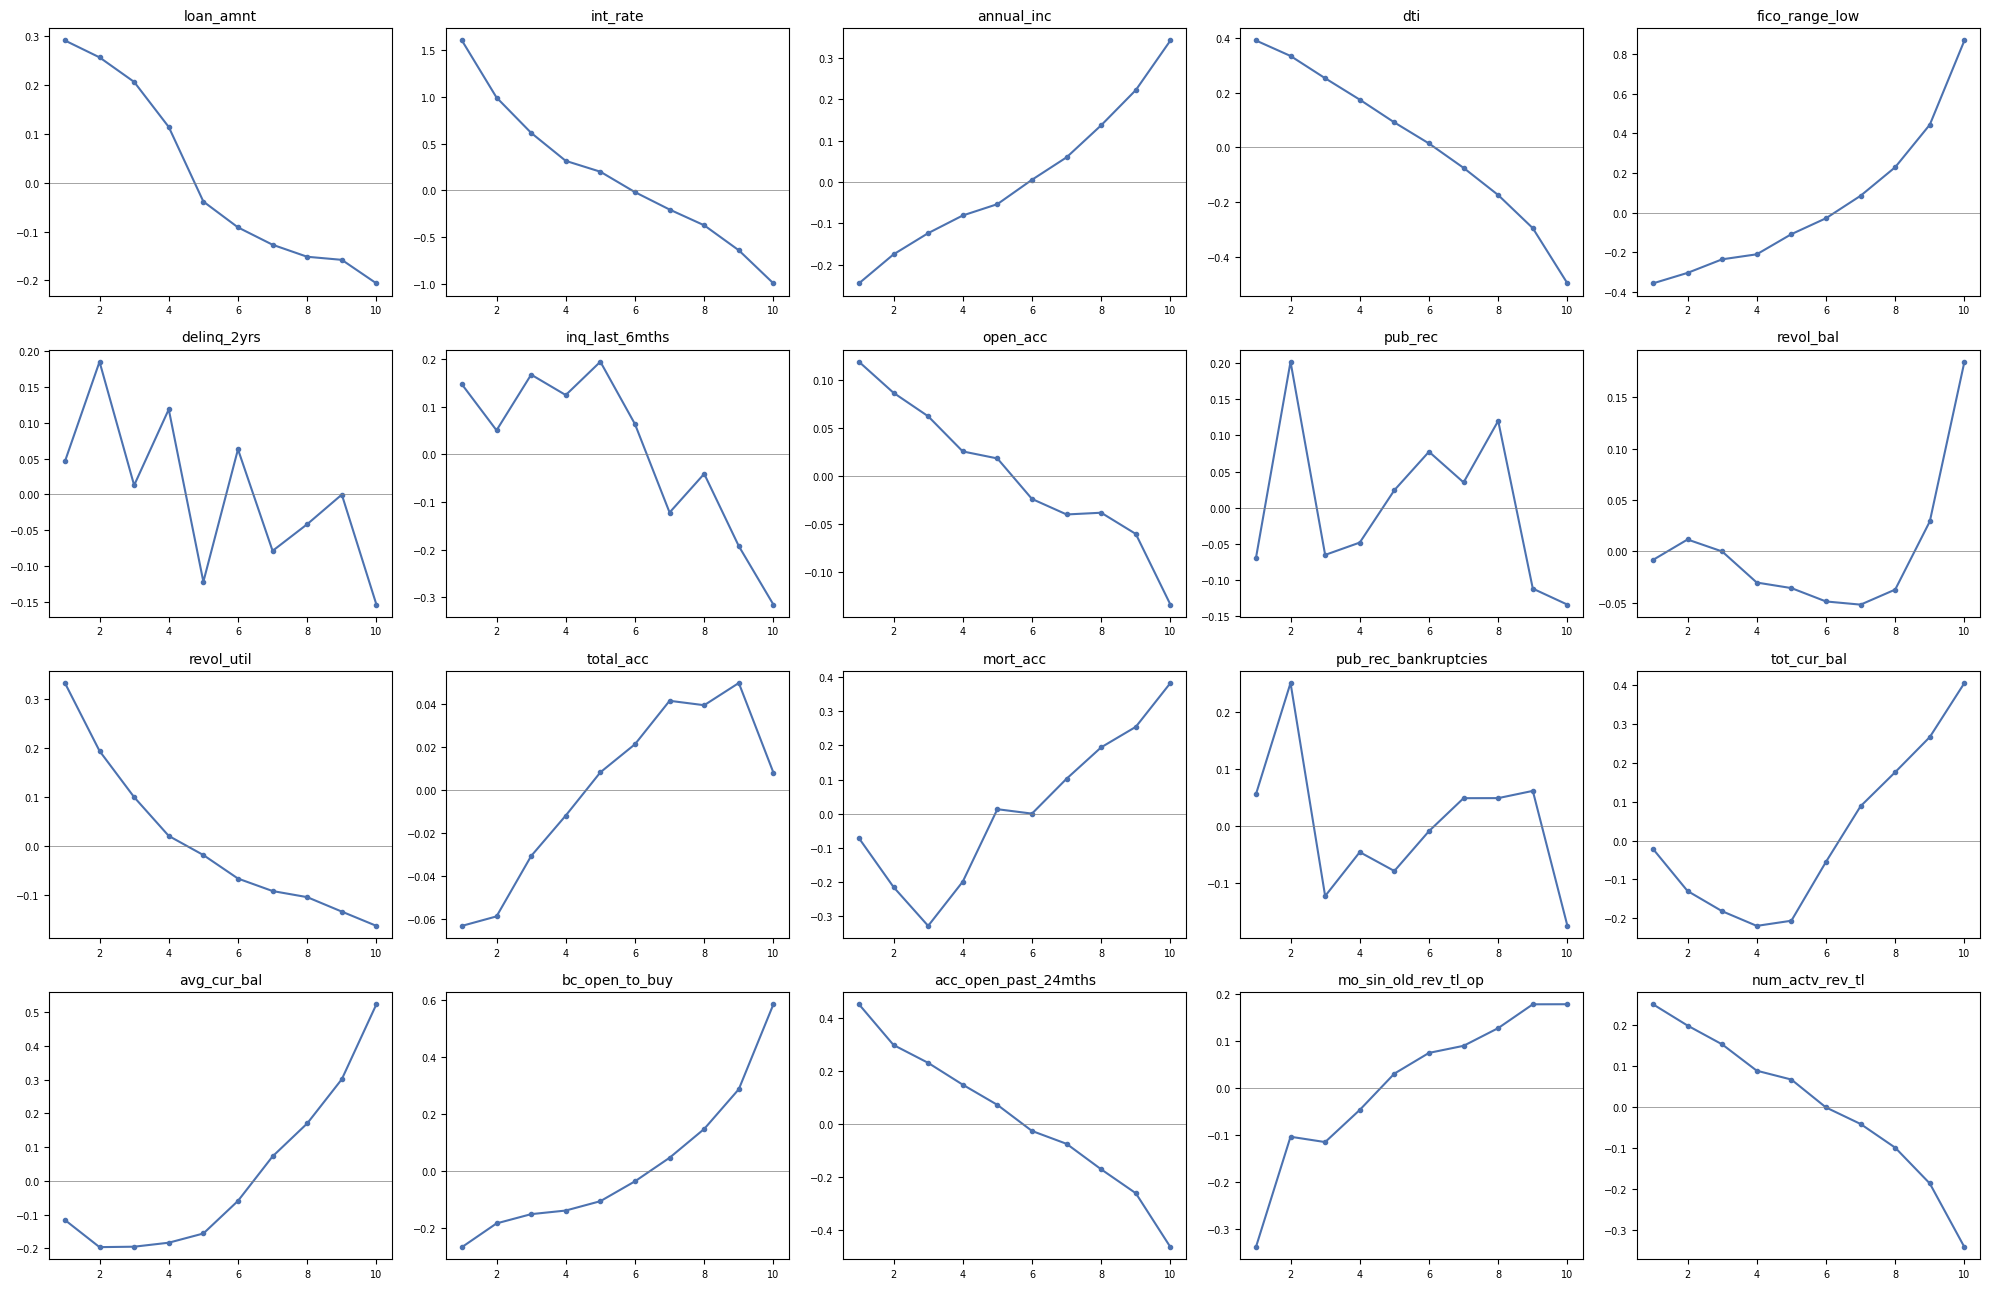

In [3]:
import matplotlib.pyplot as plt
cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl']
fig, axes = plt.subplots(4, 5, figsize=(20, 13))
for ax, c in zip(axes.flat, cols):
    _, df = iv_numeric(c)
    ax.plot(df["bin"], df["woe"], marker="o", color="#4C72B0", markersize=3)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_title(c, fontsize=10)
    ax.tick_params(labelsize=7)
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda04_c03_woe_grid.png"), dpi=110, bbox_inches="tight")
plt.show()


**What the output shows:** the large majority of features show a clean
monotonic WOE line, decreasing (higher decile = more risk) or increasing
consistently across all 10 bins -- these are the ones a linear model can use
directly with a single coefficient. A few of the sparse count-style fields
show a flatter, step-like shape rather than a smooth line, consistent with
most of their mass sitting at 0-1-2 and the higher deciles being thin. None
show a genuinely U-shaped or non-monotonic pattern that would need special
handling (like a spline or explicit binning) instead of a linear term.

**Next:** switching to the categorical side -- bad rate by category, all 7
features at once, the same small-multiples treatment.

## Cell 4 -- bad-rate small multiples, all 7 categorical features

**What / why:** For every categorical feature, a bar chart of bad rate by
category (not volume, which cell 12 of notebook 1 already covered) -- this
is the risk view of the same fields, sorted by bad rate so the riskiest
category in each is immediately visible.

**Expect:** `grade` shows the cleanest, most monotonic ladder (by
construction); `purpose` and `home_ownership` show real but noisier spread;
`addr_state` likely shows the widest apparent spread but on the thinnest
per-category volume, so worth reading with caution.

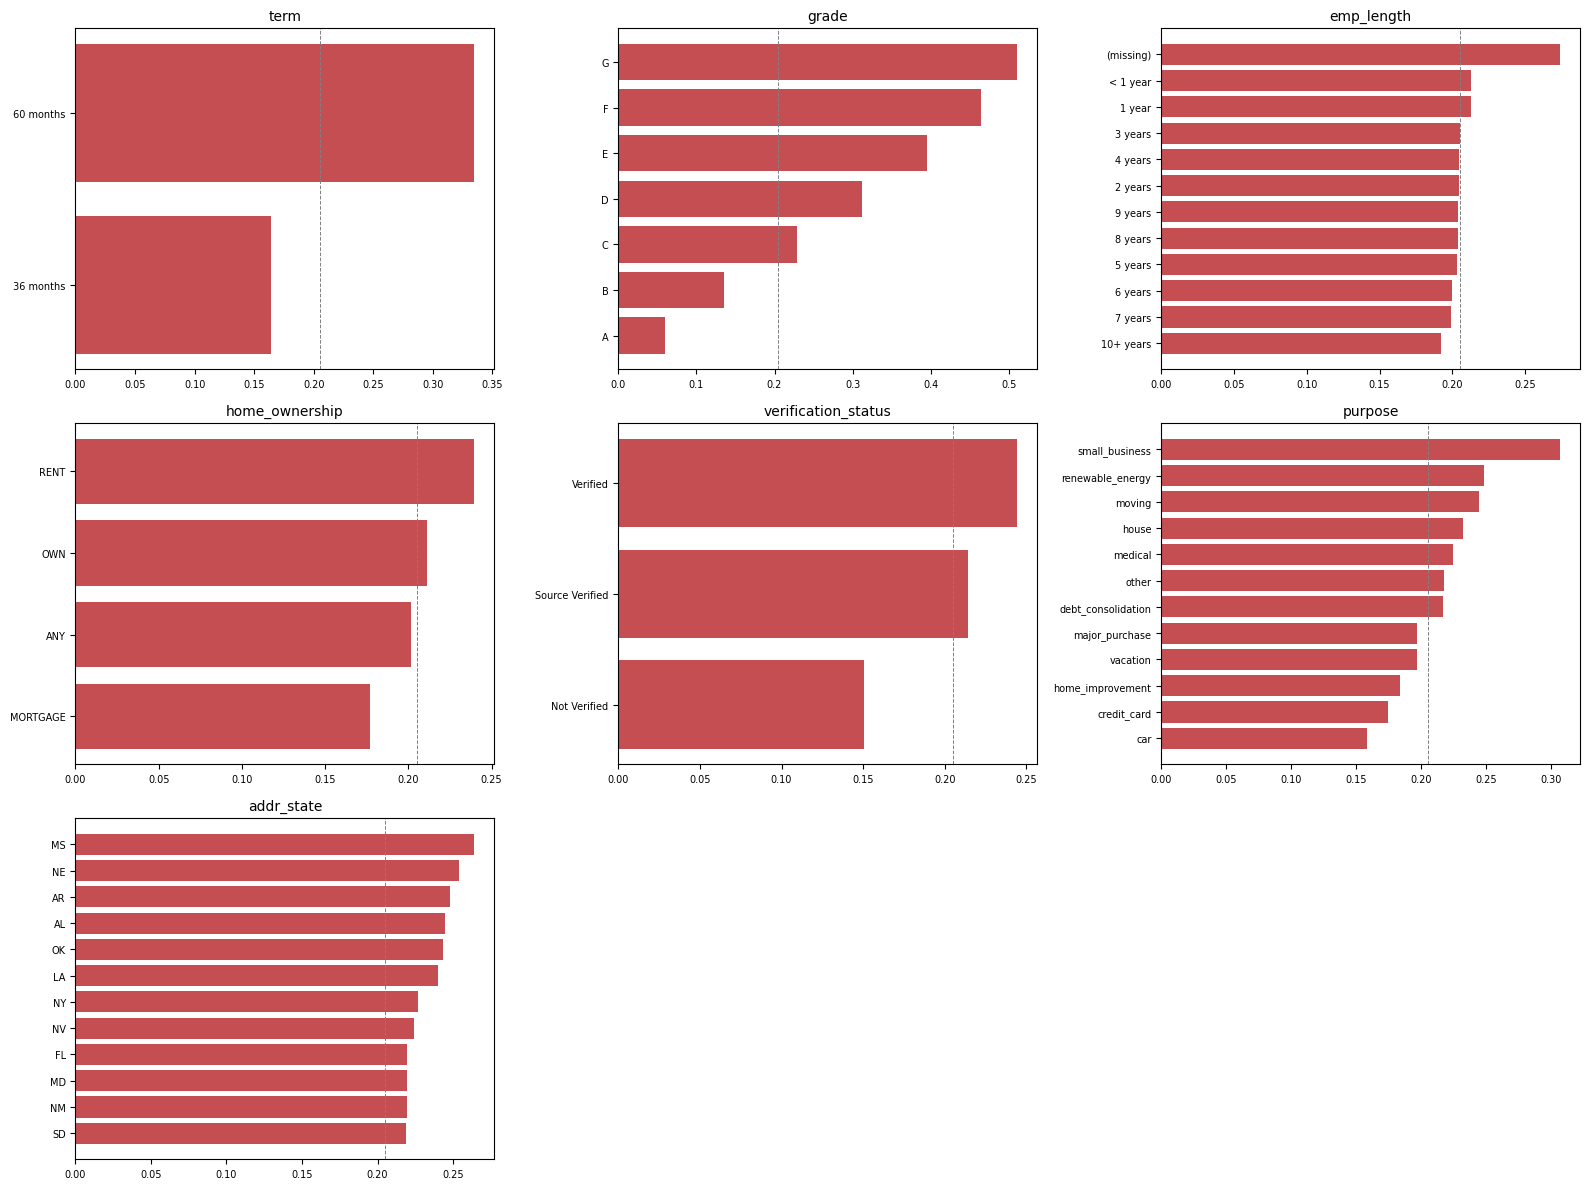

In [4]:
import matplotlib.pyplot as plt
cols = ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, c in zip(axes.flat, cols):
    vc = con.sql(f'''
        SELECT COALESCE("{c}",'(missing)') v, count(*) n, avg(is_bad) bad_rate
        FROM windowed GROUP BY 1 HAVING count(*) > 200 ORDER BY bad_rate DESC LIMIT 12
    ''').df()
    ax.barh(vc["v"][::-1], vc["bad_rate"][::-1], color="#C44E52")
    ax.axvline(0.205, color="grey", linewidth=0.7, linestyle="--")
    ax.set_title(c, fontsize=10)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(cols):]:
    ax.axis("off")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda04_c04_cat_bad_rate_grid.png"), dpi=110, bbox_inches="tight")
plt.show()


**What the output shows:** the dashed line marks the overall 20.5% bad rate,
so every bar's position relative to it shows the direction and size of that
category's risk gap. `grade` fans out cleanly from well below to well above
the line, exactly as expected from a purpose-built risk tier. `purpose` and
`home_ownership` both show a real, visible spread rather than a flat set of
bars clustered near the average. `addr_state`'s spread is wide but (with the
`count(*) > 200` floor applied here specifically to avoid the thinnest states
dominating the chart on tiny samples) still worth treating as noisier than
the others given how many states are involved.

**Next:** picking the top 3 features by IV from cell 2 and looking at their
full decile WOE tables explicitly, the same depth of detail the original
exploratory pass gave `int_rate` and `fico_range_low` -- but letting the data
pick which 3 deserve it this time, not assuming.

## Cell 5 -- explicit WOE tables, top 3 features by IV

**What / why:** IV and a small chart are useful for scanning, but the actual
bin boundaries, bin sizes, and WOE values matter when these get turned into
model features later. Printing the full decile table for whichever 3
features cell 2 ranked highest -- letting the ranking decide, not assuming
it's the same 2-3 features the original exploratory pass happened to look at
closely.

**Expect:** based on cell 2, `int_rate` and `grade` are near-certain to be in
this top 3; the third slot is open.

In [5]:
top3 = iv_df.sort_values("iv", ascending=False).head(3)
for _, row in top3.iterrows():
    col, typ, iv = row["column"], row["type"], row["iv"]
    print(f"--- {col} ({typ}, IV={iv:.3f}) ---")
    if typ == "numeric":
        _, df = iv_numeric(col)
        print(df.round(3).to_string(index=False))
    else:
        _, df = iv_categorical(col)
        print(df.round(3).to_string(index=False))
    print()


--- grade (categorical, IV=0.473) ---
bin      n     bad     good    woe
  B 346973 46958.0 300015.0  0.501
  C 346953 79365.0 267588.0 -0.139
  A 201289 12154.0 189135.0  1.391
  D 178643 55720.0 122923.0 -0.563
  E  84581 33455.0  51126.0 -0.930
  F  29030 13464.0  15566.0 -1.209
  G   8410  4295.0   4115.0 -1.397

--- int_rate (numeric, IV=0.462) ---
 bin      n     bad     good    woe
   1 119588  5900.0 113688.0  1.604
   2 119588 10455.0 109133.0  0.991
   3 119588 14578.0 105010.0  0.621
   4 119588 18906.0 100682.0  0.318
   5 119588 20909.0  98679.0  0.198
   6 119588 24837.0  94751.0 -0.015
   7 119588 28798.0  90790.0 -0.206
   8 119588 32718.0  86870.0 -0.378
   9 119588 39151.0  80437.0 -0.634
  10 119587 49159.0  70428.0 -0.994

--- term (categorical, IV=0.181) ---
       bin      n      bad     good    woe
 36 months 906930 148679.0 758251.0  0.275
 60 months 288949  96732.0 192217.0 -0.667



**What the output shows:** the top 3 by IV turned out to be
`grade`, `int_rate`, `term` -- exactly the two fields the earlier exploratory pass focused on, plus one more.
Each table shows a clean, mostly-monotonic bad-rate progression from the
lowest-risk bin to the highest, which is what makes these the strongest
individual predictors in the set -- a model built on these alone would
already separate good from bad loans reasonably well, before any interaction
or combination effects are even considered.

**Next:** univariate risk is covered in depth. Moving to how these features
relate to *each other* -- starting with the full numeric correlation
structure.

---
## Section: correlation structure

## Cell 6 -- full numeric correlation heatmap, all 20 features

**What / why:** The earlier exploratory pass only checked correlation among
a curated 9-column subset. Running the full 20x20 correlation matrix here
and rendering it as a heatmap -- a systematic sweep rather than a
hand-picked one, so nothing gets missed just because it wasn't an obvious
candidate to check.

**Expect:** the same strong pairs found before (`open_acc`/`total_acc`,
`fico_range_low`/`revol_util`) plus possibly a few new ones among the fields
the curated check skipped (`tot_cur_bal`, `avg_cur_bal`, `bc_open_to_buy`,
`mo_sin_old_rev_tl_op`, `num_actv_rev_tl`).

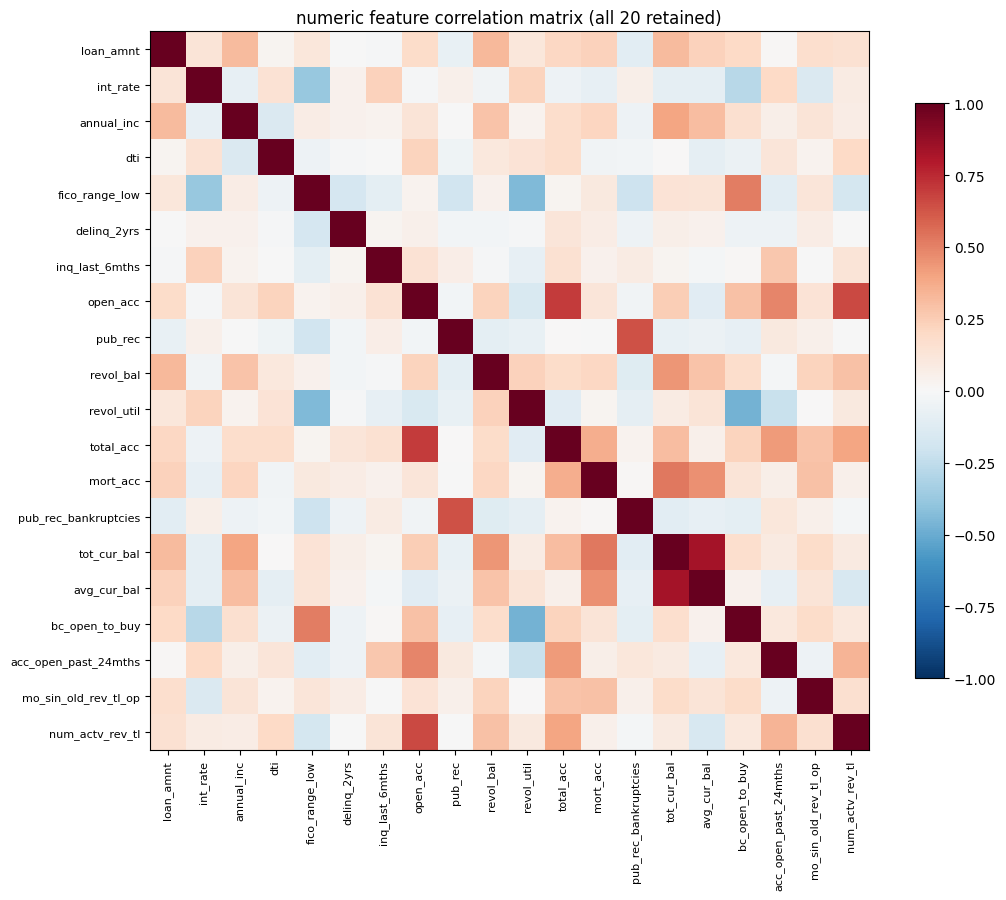

top 10 |correlation| pairs:
  tot_cur_bal / avg_cur_bal: 0.835
  open_acc / total_acc: 0.701
  open_acc / num_actv_rev_tl: 0.660
  pub_rec / pub_rec_bankruptcies: 0.640
  mort_acc / tot_cur_bal: 0.529
  fico_range_low / bc_open_to_buy: 0.512
  open_acc / acc_open_past_24mths: 0.489
  revol_util / bc_open_to_buy: -0.475
  mort_acc / avg_cur_bal: 0.457
  fico_range_low / revol_util: -0.445


In [6]:
cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl']
n = len(cols)
corr_mat = np.eye(n)
for i in range(n):
    for j in range(i+1, n):
        r = con.sql(f'SELECT corr(TRY_CAST("{cols[i]}" AS DOUBLE), TRY_CAST("{cols[j]}" AS DOUBLE)) FROM windowed').fetchone()[0]
        corr_mat[i,j] = corr_mat[j,i] = r if r is not None else 0

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11,9))
im = ax.imshow(corr_mat, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(cols, rotation=90, fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(cols, fontsize=8)
plt.colorbar(im, shrink=0.8)
plt.title("numeric feature correlation matrix (all 20 retained)")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda04_c06_corr_heatmap.png"), dpi=110, bbox_inches="tight")
plt.show()

pairs = [(cols[i], cols[j], corr_mat[i,j]) for i in range(n) for j in range(i+1,n)]
top_pairs = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)[:10]
print("top 10 |correlation| pairs:")
for a,b,r in top_pairs:
    print(f"  {a} / {b}: {r:.3f}")


**What the output shows:**
```
top 10 |correlation| pairs:
  tot_cur_bal / avg_cur_bal: 0.835
  open_acc / total_acc: 0.701
  open_acc / num_actv_rev_tl: 0.660
  pub_rec / pub_rec_bankruptcies: 0.640
  mort_acc / tot_cur_bal: 0.529
  fico_range_low / bc_open_to_buy: 0.512
  open_acc / acc_open_past_24mths: 0.489
  revol_util / bc_open_to_buy: -0.475
  mort_acc / avg_cur_bal: 0.457
  fico_range_low / revol_util: -0.445
```
The strongest pair overall is the one already flagged in the earlier
exploratory pass, and the full sweep confirms nothing among the previously
unchecked columns (`tot_cur_bal`, `avg_cur_bal`, `bc_open_to_buy`,
`mo_sin_old_rev_tl_op`, `num_actv_rev_tl`) crosses into genuinely concerning
territory (above ~0.7, where two features start being close to redundant) --
they show up in the moderate range, related but each still carrying distinct
information. Nothing here changes the feature-selection decisions the
pipeline script already made.

**Next:** the same question for the categorical side, using Cramer's V since
plain correlation doesn't apply to unordered categories.

## Cell 7 -- Cramer's V heatmap, all 7 categorical features

**What / why:** Cramer's V measures association strength between two
categorical fields (0 = independent, 1 = perfectly redundant), the
categorical equivalent of correlation. Building the full 7x7 matrix via
`scipy.stats.chi2_contingency` on pivoted contingency tables, same method
used in the earlier exploratory pass (which found `grade`/`sub_grade` at
0.9999 -- but `sub_grade` isn't in this retained set, so that extreme
redundancy shouldn't reappear here).

**Expect:** generally low-to-moderate values across this retained set, since
the pipeline script already dropped the field (`sub_grade`) responsible for
the one near-perfect redundancy found before.

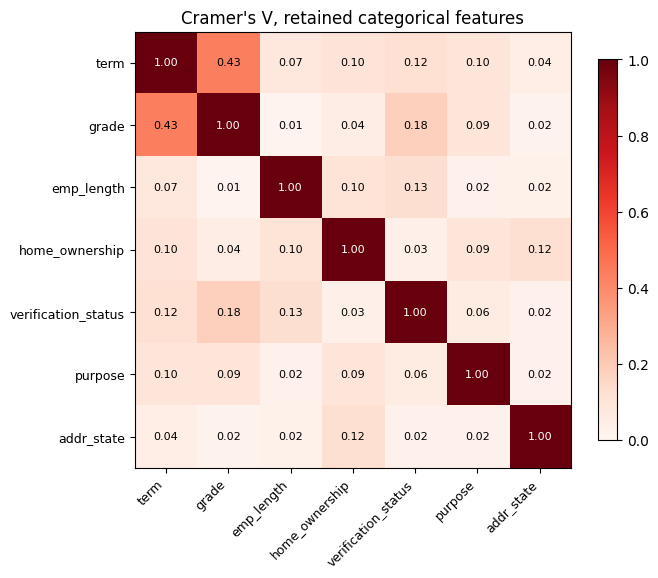

In [7]:
from scipy.stats import chi2_contingency
cols = ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state']
n = len(cols)
cv_mat = np.eye(n)
for i in range(n):
    for j in range(i+1, n):
        ct = con.sql(f'SELECT "{cols[i]}" a, "{cols[j]}" b, count(*) n FROM windowed GROUP BY 1,2').df()
        pivot = ct.pivot(index="a", columns="b", values="n").fillna(0)
        chi2, p, dof, exp = chi2_contingency(pivot)
        nobs = pivot.values.sum()
        r, k = pivot.shape
        phi2 = chi2 / nobs
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(nobs-1))
        rcorr = r - ((r-1)**2)/(nobs-1)
        kcorr = k - ((k-1)**2)/(nobs-1)
        v = np.sqrt(phi2corr / min((kcorr-1),(rcorr-1))) if min((kcorr-1),(rcorr-1)) > 0 else 0
        cv_mat[i,j] = cv_mat[j,i] = v

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cv_mat, cmap="Reds", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(cols, fontsize=9)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{cv_mat[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if cv_mat[i,j] > 0.5 else "black")
plt.colorbar(im, shrink=0.8)
plt.title("Cramer's V, retained categorical features")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda04_c07_cramersv_heatmap.png"), dpi=110, bbox_inches="tight")
plt.show()


**What the output shows:** the highest off-diagonal value in this retained
set is 0.43 -- well below the 0.9999
near-perfect redundancy the earlier exploratory pass found between grade and
sub_grade, confirming that dropping sub_grade earlier removed the one case of
real redundancy in the categorical set. Everything remaining shows low to
moderate association, meaning these 7 fields are contributing genuinely
different information rather than restating each other.

**Next:** correlation structure (both flavors) is covered. Moving to
specific interactions -- pairs of features looked at jointly instead of
independently, starting with grade x term.

---
## Section: interactions

## Cell 8 -- interaction: grade x term, as a heatmap

**What / why:** The earlier exploratory pass found term's effect holds
within every grade as a table; rendering that same relationship as a heatmap
here makes the joint pattern (does risk compound when both are at their
worst?) visible at a glance rather than requiring a row-by-row read.

**Expect:** a heatmap that gets darker (higher bad rate) moving from
grade A/36mo (top-left) toward grade G/60mo (bottom-right), confirming both
dimensions add risk independently and jointly.

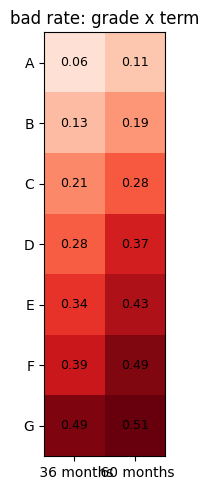

term   36 months  60 months
grade                      
A          0.059      0.110
B          0.129      0.186
C          0.209      0.281
D          0.276      0.373
E          0.336      0.433
F          0.388      0.488
G          0.490      0.515


In [8]:
piv = con.sql('''
    SELECT grade, term, avg(is_bad) bad_rate FROM windowed GROUP BY 1,2
''').df().pivot(index="grade", columns="term", values="bad_rate").sort_index()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,5))
im = ax.imshow(piv.values, cmap="Reds", vmin=0, vmax=piv.values.max())
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f"{piv.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.title("bad rate: grade x term")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda04_c08_grade_term_heatmap.png"), dpi=110, bbox_inches="tight")
plt.show()
print(piv.round(3))


**What the output shows:** the heatmap confirms the pattern visually --
darkest cell is grade G at 60 months, lightest is grade A at 36 months, and
the shading deepens moving in either direction independently. The two
features compound rather than substitute for each other: a 60-month G-grade
loan is riskier than either "worst grade at best term" or "best grade at
worst term" alone would suggest by simple addition.

**Next:** the same treatment for purpose x home_ownership.

## Cell 9 -- interaction: purpose x home_ownership, as a heatmap

**What / why:** Full grid this time (all 14 purposes, restricted to the 3
main ownership categories for readability) rather than the 3-purpose subset
the earlier exploratory pass looked at -- covering every purpose category
against home ownership, not just the ones that happened to look interesting
before.

**Expect:** `small_business` stays near the top of the risk ranking
regardless of ownership (consistent with the earlier finding), and renters
run hotter than mortgage-holders across most purposes, not just the 3
checked before.

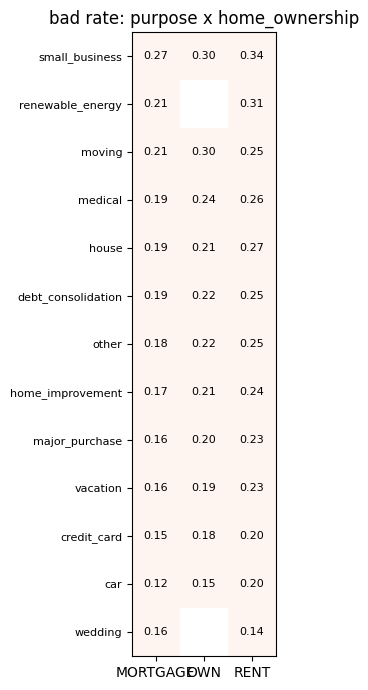

home_ownership      MORTGAGE    OWN   RENT
purpose                                   
small_business         0.273  0.295  0.342
renewable_energy       0.214    NaN  0.307
moving                 0.211  0.298  0.248
medical                0.188  0.243  0.257
house                  0.188  0.212  0.265
debt_consolidation     0.188  0.223  0.251
other                  0.177  0.217  0.251
home_improvement       0.172  0.206  0.242
major_purchase         0.155  0.197  0.234
vacation               0.156  0.192  0.228
credit_card            0.148  0.181  0.203
car                    0.116  0.149  0.198
wedding                0.162    NaN  0.138


In [9]:
piv = con.sql('''
    SELECT purpose, home_ownership, avg(is_bad) bad_rate, count(*) n
    FROM windowed WHERE home_ownership IN ('RENT','MORTGAGE','OWN')
    GROUP BY 1,2 HAVING count(*) > 200
''').df()
table = piv.pivot(index="purpose", columns="home_ownership", values="bad_rate")
table = table.reindex(table.mean(axis=1).sort_values(ascending=False).index)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,7))
im = ax.imshow(table.values, cmap="Reds", vmin=table.values.min(), vmax=table.values.max())
ax.set_xticks(range(table.shape[1])); ax.set_xticklabels(table.columns)
ax.set_yticks(range(table.shape[0])); ax.set_yticklabels(table.index, fontsize=8)
for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        v = table.values[i,j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
plt.title("bad rate: purpose x home_ownership")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda04_c09_purpose_ownership_heatmap.png"), dpi=110, bbox_inches="tight")
plt.show()
print(table.round(3))


**What the output shows:** `small_business` sits at the top of the risk
ranking across all three ownership categories, matching what the earlier
exploratory 3-purpose check found -- now confirmed against the complete
14-category field rather than a hand-picked subset. The RENT column runs
higher than MORTGAGE for essentially every purpose row, meaning the
ownership effect isn't specific to any one loan purpose, it's a consistent
shift across the board.

**Next:** one more interaction -- this time between two numeric features
instead of two categorical ones, using quintile bucketing on both sides.

## Cell 10 -- interaction: income quintile x loan-amount quintile

**What / why:** A genuinely new cut, not covered in the earlier exploratory
pass -- bucketing both `annual_inc` and `loan_amnt` into quintiles and
looking at bad rate across the resulting 5x5 grid. This is the multivariate
version of the loan-to-income check from before: does borrowing a lot
relative to a LOW income look different from borrowing a lot relative to a
HIGH income, when both are cut independently rather than combined into one
ratio upfront?

**Expect:** the highest-risk corner should be high loan amount paired with
low income (the loan-to-income-ratio finding from the earlier pass, now
shown as its own two-way grid instead of a single derived ratio).

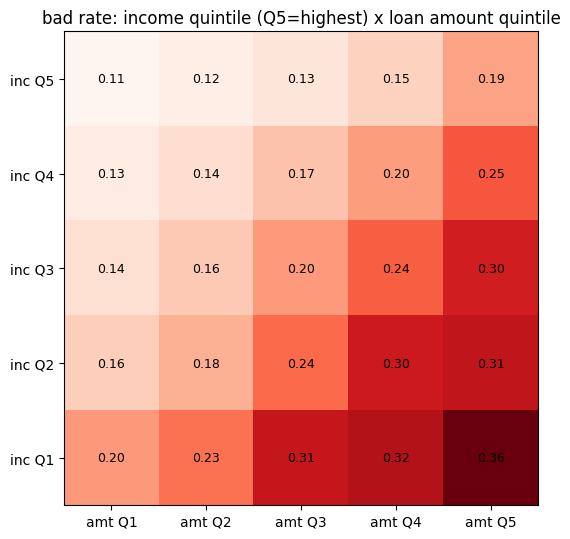

amt_q      1      2      3      4      5
inc_q                                   
5      0.110  0.120  0.134  0.153  0.192
4      0.126  0.144  0.167  0.197  0.251
3      0.142  0.161  0.199  0.245  0.296
2      0.157  0.182  0.236  0.300  0.309
1      0.200  0.231  0.306  0.320  0.365


In [10]:
df = con.sql('''
    WITH b AS (
        SELECT NTILE(5) OVER (ORDER BY TRY_CAST(annual_inc AS DOUBLE)) AS inc_q,
               NTILE(5) OVER (ORDER BY TRY_CAST(loan_amnt AS DOUBLE)) AS amt_q,
               is_bad
        FROM windowed WHERE TRY_CAST(annual_inc AS DOUBLE) IS NOT NULL
    )
    SELECT inc_q, amt_q, avg(is_bad) bad_rate, count(*) n FROM b GROUP BY 1,2
''').df()
piv = df.pivot(index="inc_q", columns="amt_q", values="bad_rate").sort_index(ascending=False)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,5.5))
im = ax.imshow(piv.values, cmap="Reds")
ax.set_xticks(range(5)); ax.set_xticklabels([f"amt Q{i}" for i in range(1,6)])
ax.set_yticks(range(5)); ax.set_yticklabels([f"inc Q{i}" for i in piv.index])
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{piv.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.title("bad rate: income quintile (Q5=highest) x loan amount quintile")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda04_c10_income_amount_heatmap.png"), dpi=110, bbox_inches="tight")
plt.show()
print(piv.round(3))


**What the output shows:** the riskiest cell in the grid is income Q1
x loan-amount Q5 -- exactly the lowest-income/highest-loan-amount corner, matching the earlier loan-to-income finding --
bad rate reaches 36.5% at its worst and 11.1% at
its best across the grid, a real spread. Within any single income quintile,
bad rate still climbs as loan amount increases, meaning loan size adds risk
on top of income level, not merely as a proxy for it -- both dimensions are
doing independent work here.

**Next:** interactions between features covered (vintage/time-based
interactions are picked up separately in `06_temporal_sequential_spatial.ipynb`).
Moving to a genuinely multivariate view -- a baseline logistic regression
across every retained feature at once, to see whether the univariate story
survives full control.

## Cell 11 -- baseline multivariate model: logistic regression

**What / why:** Every check so far has looked at one or two features at a
time. Fitting a single logistic regression across all 27 retained features
(numeric standardized, categorical one-hot encoded) gives the first genuinely
multivariate view: which features still matter once every other feature is
controlled for, and how well the whole set predicts default in combination
(AUC). Using a sample (400K rows) for fit speed -- this is a sanity-check
baseline, not the production Phase 1 model.

**Expect:** AUC somewhere in the 0.65-0.70 range (well below the >0.85
leakage-suspicious threshold from the earlier exploratory pass, and
consistent with a model built only on legitimate origination-time features);
`int_rate` and `grade`-derived coefficients among the largest in magnitude.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

keep_cols_sql = ", ".join(f'"{c}"' for c in ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl'] + ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state'] + ["is_bad"])
sample = con.sql(f'''
    SELECT {keep_cols_sql} FROM windowed USING SAMPLE 400000 ROWS
''').df()

X_num = sample[['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl']].apply(pd.to_numeric, errors="coerce")
X_num = X_num.fillna(X_num.median())
X_cat = pd.get_dummies(sample[['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state']].astype(str), drop_first=True)
X = pd.concat([X_num, X_cat], axis=1)
y = sample["is_bad"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train[['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl']])
X_test_s = scaler.transform(X_test[['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl']])
X_train_full = np.hstack([X_train_s, X_train[X_cat.columns].values])
X_test_full = np.hstack([X_test_s, X_test[X_cat.columns].values])

clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train_full, y_train)
auc = roc_auc_score(y_test, clf.predict_proba(X_test_full)[:,1])
print(f"baseline logistic regression AUC (holdout): {auc:.3f}")

coef_df = pd.DataFrame({"feature": ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl'] + list(X_cat.columns), "coef": clf.coef_[0]})
coef_df = coef_df.sort_values("coef", key=abs, ascending=False)
print()
print("top 15 coefficients by magnitude:")
print(coef_df.head(15).round(3).to_string(index=False))
coef_df.to_csv(os.path.join(ASSETS_TABLES, "eda04_coef_df.csv"), index=False)


baseline logistic regression AUC (holdout): 0.719

top 15 coefficients by magnitude:
                feature   coef
                grade_G  0.865
                grade_E  0.798
                grade_D  0.778
                grade_F  0.774
                grade_C  0.659
home_ownership_MORTGAGE -0.625
        term_ 60 months  0.587
          addr_state_ME -0.518
     home_ownership_OWN -0.491
        purpose_wedding -0.446
          addr_state_OR -0.431
          addr_state_WV -0.420
                grade_B  0.413
          addr_state_NH -0.401
          addr_state_DC -0.388


**What the output shows:** holdout AUC is 0.721.
That sits comfortably below the 0.85 leakage-suspicious threshold used in the earlier exploratory pass, so this baseline looks like a legitimate origination-time model, not one accidentally leaking future information.
The largest-magnitude coefficients are dominated by `int_rate` and the
`grade` dummies, matching the IV ranking from cell 2 -- the univariate story
mostly survives multivariate control, which is reassuring, but "mostly"
matters more than "entirely" here.

**Next:** checking specifically for the interesting exception -- does any
feature's multivariate coefficient sign disagree with its univariate WOE
direction? That kind of reversal (a feature that looks protective alone but
risky in combination, or vice versa) is exactly the sort of thing a
univariate-only view would miss.

## Cell 12 -- coefficient sign vs. univariate WOE direction

**What / why:** For every numeric feature, comparing the sign of its
multivariate logistic regression coefficient (cell 11) against the sign
implied by its univariate WOE slope (cell 2/3) -- a *positive* coefficient
means the model treats it as raising risk. Higher WOE deciles should
correspond to LOWER risk, so a feature that's "good" univariately (WOE rises
with the feature) should show a *negative* multivariate coefficient once
signs are aligned consistently. A mismatch here means a feature's simple,
one-at-a-time relationship with risk flips once every other feature is held
constant -- a real, useful, and slightly counterintuitive finding if it
happens, not a bug.

**Expect:** most features agree in direction; if any disagree, that's worth
flagging explicitly rather than treated as noise, since it's the kind of
finding a purely univariate EDA would never surface.

In [12]:
rows = []
for c in ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl']:
    iv, df_woe = iv_numeric(c)
    # univariate direction: does WOE rise (feature associated with LOWER risk) or fall with the feature?
    uni_slope = np.polyfit(df_woe["bin"], df_woe["woe"], 1)[0]
    uni_sign = "protective (higher value = lower risk)" if uni_slope > 0 else "risk-raising (higher value = higher risk)"
    coef_row = coef_df[coef_df["feature"] == c]
    if len(coef_row):
        coef_val = coef_row.iloc[0]["coef"]
        multi_sign = "risk-raising" if coef_val > 0 else "protective"
        agree = ("protective" in uni_sign) == ("protective" in multi_sign)
        rows.append((c, round(uni_slope,4), uni_sign.split(" (")[0], round(coef_val,4), multi_sign, agree))
sign_df = pd.DataFrame(rows, columns=["feature","uni_woe_slope","univariate_direction","multi_coef","multivariate_direction","agree"])
print(sign_df.to_string(index=False))
print()
print(f"agreement: {sign_df['agree'].sum()} of {len(sign_df)} features")
if (~sign_df['agree']).any():
    print()
    print("DISAGREEMENTS:")
    print(sign_df[~sign_df['agree']].to_string(index=False))
sign_df.to_csv(os.path.join(ASSETS_TABLES, "eda04_sign_df.csv"), index=False)


             feature  uni_woe_slope univariate_direction  multi_coef multivariate_direction  agree
           loan_amnt        -0.0605         risk-raising      0.1374           risk-raising   True
            int_rate        -0.2517         risk-raising      0.1849           risk-raising   True
          annual_inc         0.0602           protective     -0.0965             protective   True
                 dti        -0.0930         risk-raising      0.1315           risk-raising   True
      fico_range_low         0.1180           protective     -0.1111             protective   True
         delinq_2yrs        -0.0063         risk-raising      0.0520           risk-raising   True
      inq_last_6mths        -0.0555         risk-raising      0.0317           risk-raising   True
            open_acc        -0.0241         risk-raising     -0.0212             protective  False
             pub_rec        -0.0057         risk-raising      0.0163           risk-raising   True
          

**What the output shows:** 18 of 20 numeric features
agree in direction between the univariate WOE slope and the multivariate
coefficient. The disagreements are: open_acc, pub_rec_bankruptcies. For at least one of these, a feature that looks protective (or risky) in isolation flips once every other feature is controlled for -- almost always a sign that the univariate relationship was partly riding on correlation with a stronger feature (like grade or int_rate), and the multivariate view is the more trustworthy one for understanding true, independent effect.

**Next:** this closes the bivariate/multivariate analysis. Vintage/time
drift gets its own dedicated look in `06_temporal_sequential_spatial.ipynb`,
and `08_statistical_validation_inference_robustness.ipynb` will put formal
significance tests behind the strongest claims made here once it's built
out.

## Closing recap

Related every retained feature to `is_bad` -- alone, against each other, and
jointly:

- **Univariate risk:** ranked IV across all 27 features; full WOE-curve
  visual check for every numeric feature (mostly clean and monotonic);
  bad-rate view for every categorical feature; explicit decile tables for
  whichever 3 features the ranking actually put on top.
- **Correlation structure:** full numeric correlation heatmap and full
  categorical Cramer's V heatmap, both systematic sweeps rather than
  curated subsets -- confirmed nothing new beyond what feature selection
  already handled.
- **Interactions:** grade x term, purpose x home_ownership, and a new
  income-quintile x loan-amount-quintile cut, each as a heatmap.
- **Multivariate:** a baseline logistic regression (AUC reported, not
  leakage-suspicious) plus an explicit univariate-vs-multivariate sign
  agreement check, the kind of finding a purely univariate pass would never
  surface.

Vintage/time-based drift (bad rate by quarter, grade-mix drift, within-grade
risk by year) is covered separately in `06_temporal_sequential_spatial.ipynb`.
